# Notebook 5 - XGboost Machine learning model

This notebook is the main notebook that shows the process of how the XGBoost ML model was created and tested

The predicitons are saved in /results/models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import leafmap.foliumap as leafmap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV




## V1 Baseline model 

In [2]:
#raw data
filepath = "../data/raw/GT_V1_data_cph.csv"
data = pd.read_csv(filepath)


In [3]:
data.head()

,cluster_id,EMUB_reg_1990_1995,EMUB_reg_1995_2000,EMUB_reg_2000_2005,EMUB_reg_2005_2010,EMUB_reg_2010_2015,EMUB_reg_2015_2020,PMB_reg_1990_1995,PMB_reg_1995_2000,PMB_reg_2000_2005,...,public_housing_reg_2000_2005,public_housing_reg_2005_2010,public_housing_reg_2010_2015,public_housing_reg_2015_2020,unemp_reg_1990_1995,unemp_reg_1995_2000,unemp_reg_2000_2005,unemp_reg_2005_2010,unemp_reg_2010_2015,unemp_reg_2015_2020
0,101_1,28.597450,-29.508971,-8.305425,-10.737765,-18.739771,21.651561,1.006311,0.810537,1.273032,...,1.980198,-0.970874,-2.941176,0.000000,7.238606,-33.500000,-17.293233,44.090909,-48.895899,136.419753
1,101_10,6.118231,-3.252824,3.160862,-1.795472,-7.849762,-7.569549,40.231621,-12.639138,4.562269,...,NaN,NaN,NaN,NaN,-5.742574,-42.436975,32.116788,83.425414,-23.493976,6.496063
2,101_100,16.270826,-9.405488,1.413428,0.696864,9.424946,-1.370276,-25.301205,17.096774,24.903581,...,0.000000,0.000000,0.000000,0.000000,12.266227,-53.552180,-53.691983,58.086560,-12.536023,-8.731466
3,101_1000,18.296847,-0.560272,13.539355,-6.451128,-3.552484,-16.666667,35.381356,101.251956,-20.762053,...,NaN,NaN,NaN,NaN,38.921002,-1.803051,-27.118644,11.434109,-54.956522,148.648649
4,101_1001,-4.456372,-2.743663,6.824288,-2.665996,3.165375,-4.946775,24.788136,-7.809847,-21.362799,...,9.848485,1.379310,0.000000,-1.360544,-25.000000,-70.940171,11.029412,92.052980,-30.689655,-31.343284


In [4]:
data.shape

(1421, 115)

In [5]:
print(data.columns)

Index(['cluster_id', 'EMUB_reg_1990_1995', 'EMUB_reg_1995_2000',
       'EMUB_reg_2000_2005', 'EMUB_reg_2005_2010', 'EMUB_reg_2010_2015',
       'EMUB_reg_2015_2020', 'PMB_reg_1990_1995', 'PMB_reg_1995_2000',
       'PMB_reg_2000_2005',
       ...
       'public_housing_reg_2000_2005', 'public_housing_reg_2005_2010',
       'public_housing_reg_2010_2015', 'public_housing_reg_2015_2020',
       'unemp_reg_1990_1995', 'unemp_reg_1995_2000', 'unemp_reg_2000_2005',
       'unemp_reg_2005_2010', 'unemp_reg_2010_2015', 'unemp_reg_2015_2020'],
      dtype='object', length=115)


In [6]:
# import data from STA with 'mean_sd_class_idx'
filepath_sta = "../data/interim/STA_data.csv"
STA_data = pd.read_csv(filepath_sta)

STA_data.head()

,Unnamed: 0,Shape_Area,Shape_Leng,cluster_id,fid_1,id_munic,munic_clus,munic_code,min,max,mean,count,std,range,mean_sd_class,mean_sd_class_idx,mean_sd_class3_idx,mean_sd_class3
0,0,70000.0,1400.0,101_1,1.0,1.0,101_1,101.0,3.568477,3.568477,3.568477,7,1.702990e-07,0.0,"(mu+1σ, mu+2σ] (high)",2,2,High
1,1,110000.0,1800.0,101_2,2.0,2.0,101_2,101.0,3.555815,3.555815,3.555814,11,6.285581e-07,0.0,"(mu+1σ, mu+2σ] (high)",2,2,High
2,2,30000.0,800.0,101_3,3.0,3.0,101_3,101.0,2.947018,2.947018,2.947018,3,7.947286e-08,0.0,"(mu, mu+1σ] (slightly high)",1,1,Medium
3,3,50000.0,1000.0,101_4,4.0,4.0,101_4,101.0,3.260913,3.260913,3.260913,5,4.768372e-08,0.0,"(mu+1σ, mu+2σ] (high)",2,2,High
4,4,20000.0,600.0,101_5,5.0,5.0,101_5,101.0,2.443852,2.443852,2.443852,2,0.000000e+00,0.0,"(mu-1σ, mu] (slightly low)",1,1,Medium


In [7]:
# Join 'mean_sd_class_idx' onto the dataset via 'cluster_id' with robust key handling

def _ensure_cluster_id(df):
    if 'cluster_id' in df.columns:
        return df
    # Case-insensitive exact match
    matches = [c for c in df.columns if c.lower() == 'cluster_id']
    if matches:
        df = df.rename(columns={matches[0]: 'cluster_id'})
        return df
    # Heuristic fallback: any column containing 'cluster' or 'munic'
    heur = [c for c in df.columns if ('cluster' in c.lower()) or ('munic' in c.lower())]
    if heur:
        print(f"INFO: Using '{heur[0]}' as 'cluster_id'")
        df = df.rename(columns={heur[0]: 'cluster_id'})
        return df
    raise KeyError("No join key found. Expected a 'cluster_id' column (case-insensitive) or one containing 'cluster'/'munic'.")

# Normalize join keys
data = _ensure_cluster_id(data)
STA_data = _ensure_cluster_id(STA_data)

# Determine which label column to use from STA_data
label_col = 'mean_sd_class_idx'
if label_col not in STA_data.columns:
    if 'mean_sd_class3_idx' in STA_data.columns:
        print("WARNING: 'mean_sd_class_idx' not found in STA_data; using 'mean_sd_class3_idx' instead.")
        label_col = 'mean_sd_class3_idx'
    else:
        raise KeyError("STA_data is missing 'mean_sd_class_idx' (and 'mean_sd_class3_idx'). Available columns: " + str(list(STA_data.columns)))

# Prepare right-side frame and align column name to 'mean_sd_class_idx' for consistency
right = STA_data[['cluster_id', label_col]].copy()
if label_col != 'mean_sd_class_idx':
    right = right.rename(columns={label_col: 'mean_sd_class_idx'})

# Merge
n_before = len(data)
data = data.merge(right, on='cluster_id', how='left')
missing = data['mean_sd_class_idx'].isna().sum()
print(f"Merged rows: {len(data)} (was {n_before}). Missing labels after merge: {missing}")

# Preview
data[['cluster_id', 'mean_sd_class_idx']].head()

Merged rows: 1421 (was 1421). Missing labels after merge: 0


,cluster_id,mean_sd_class_idx
0,101_1,2
1,101_10,1
2,101_100,1
3,101_1000,1
4,101_1001,2


In [8]:
X = data.drop(columns= {'cluster_id', 'mean_sd_class_idx' }, axis=1)
y = data['mean_sd_class_idx']

In [9]:
X.head()

,EMUB_reg_1990_1995,EMUB_reg_1995_2000,EMUB_reg_2000_2005,EMUB_reg_2005_2010,EMUB_reg_2010_2015,EMUB_reg_2015_2020,PMB_reg_1990_1995,PMB_reg_1995_2000,PMB_reg_2000_2005,PMB_reg_2005_2010,...,public_housing_reg_2000_2005,public_housing_reg_2005_2010,public_housing_reg_2010_2015,public_housing_reg_2015_2020,unemp_reg_1990_1995,unemp_reg_1995_2000,unemp_reg_2000_2005,unemp_reg_2005_2010,unemp_reg_2010_2015,unemp_reg_2015_2020
0,28.597450,-29.508971,-8.305425,-10.737765,-18.739771,21.651561,1.006311,0.810537,1.273032,-2.596758,...,1.980198,-0.970874,-2.941176,0.000000,7.238606,-33.500000,-17.293233,44.090909,-48.895899,136.419753
1,6.118231,-3.252824,3.160862,-1.795472,-7.849762,-7.569549,40.231621,-12.639138,4.562269,16.666667,...,NaN,NaN,NaN,NaN,-5.742574,-42.436975,32.116788,83.425414,-23.493976,6.496063
2,16.270826,-9.405488,1.413428,0.696864,9.424946,-1.370276,-25.301205,17.096774,24.903581,-6.528452,...,0.000000,0.000000,0.000000,0.000000,12.266227,-53.552180,-53.691983,58.086560,-12.536023,-8.731466
3,18.296847,-0.560272,13.539355,-6.451128,-3.552484,-16.666667,35.381356,101.251956,-20.762053,31.108930,...,NaN,NaN,NaN,NaN,38.921002,-1.803051,-27.118644,11.434109,-54.956522,148.648649
4,-4.456372,-2.743663,6.824288,-2.665996,3.165375,-4.946775,24.788136,-7.809847,-21.362799,-16.042155,...,9.848485,1.379310,0.000000,-1.360544,-25.000000,-70.940171,11.029412,92.052980,-30.689655,-31.343284


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify = y_train)    

In [11]:
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

#objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,  forskellig parametre vi kan bruge

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [12]:
y_pred = model.predict(X_val)

test_accuracy = accuracy_score(y_val, y_pred)



Test Accuracy: 
 0.7640845070422535

Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.43      0.54        51
           1       0.76      0.93      0.84       182
           2       0.81      0.51      0.63        51

    accuracy                           0.76       284
   macro avg       0.77      0.62      0.67       284
weighted avg       0.77      0.76      0.75       284


Confusion Matrix: 


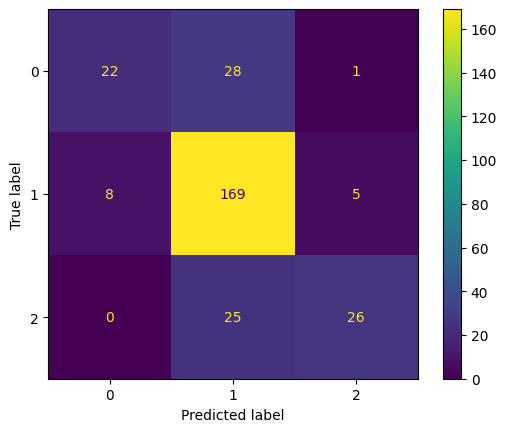

In [13]:
#print test accuracy
print("\nTest Accuracy: \n", test_accuracy)  

# print classification report
print("\nClassification Report: \n", classification_report(y_val, y_pred))

# print confusion matrix
print("\nConfusion Matrix: \n", ConfusionMatrixDisplay.from_predictions(y_val, y_pred))



### Baseline + hyperparameter tuning

In [14]:
# Hyper parameter tuning

param_grid = {
    'n_estimators': [100, 200, 300, 500], # number of trees
    'learning_rate': [0.01, 0.1, 0.2], # how fast the model changes weights
    'max_depth': [3, 6, 9], # the depth of each tree
    'min_child_weight': [1, 3, 5], # minimum weight for a node to be split
    'subsample': [0.7, 0.85, 1.0], # part of training data used for each tree
    'colsample_bytree': [0.7, 0.85, 1.0], # number of features used per tree
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100], # L1 regularization 
    'reg_lambda': [0.5, 0.7, 1, 1.3] # L2 regularization
}

In [15]:
model = XGBClassifier(random_state=42)

#Tests 100 different combinations of hyperparameters from the param_grid using 10-fold cross-validation and evaluates them using the macro F1 score.

grid_seach = RandomizedSearchCV(model, param_grid, cv = 10, scoring='f1_macro', n_iter=100, n_jobs= -1, verbose = 2, random_state = 42)
grid_seach.fit(X_train, y_train)

v1_model = grid_seach.best_estimator_

print("Best Hyperparameters: ", grid_seach.best_params_)
print("best accuracy: ", grid_seach.best_score_ )

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=   9.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=   9.5s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=   9.7s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=   9.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=   9.7s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500


Test Accuracy:
 0.743859649122807

Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.47      0.62        51
           1       0.75      0.91      0.82       183
           2       0.59      0.43      0.50        51

    accuracy                           0.74       285
   macro avg       0.76      0.60      0.65       285
weighted avg       0.75      0.74      0.73       285


Test Confusion Matrix:


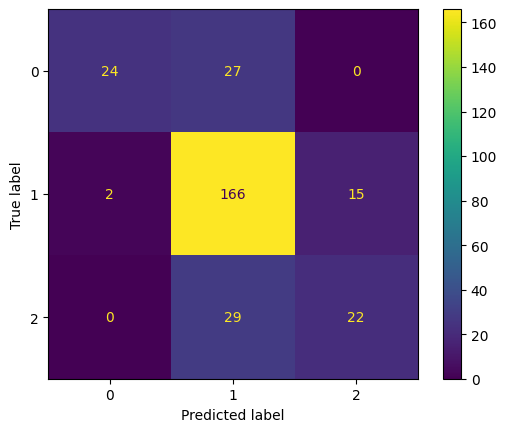

In [16]:
# New prediction with the tuned model

# Generate predictions test splits
y_test_pred_best = v1_model.predict(X_test)

# Compute accuracies
test_accuracy = accuracy_score(y_test, y_test_pred_best)


# Print test metrics (y_test vs y_test_pred_best)
print("\nTest Accuracy:\n", test_accuracy)
print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred_best))
print("\nTest Confusion Matrix:\n", ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_best))

### Hyperparameter + class_weight 

Class weights: {np.int64(0): np.float64(2.8211920529801326), np.int64(1): np.float64(0.5201465201465202), np.int64(2): np.float64(1.832258064516129)}

Classification Report (weighted, test):
               precision    recall  f1-score   support

           0       0.78      0.61      0.68        51
           1       0.78      0.85      0.81       183
           2       0.58      0.51      0.54        51

    accuracy                           0.75       285
   macro avg       0.71      0.66      0.68       285
weighted avg       0.74      0.75      0.74       285


Confusion Matrix (weighted, test):


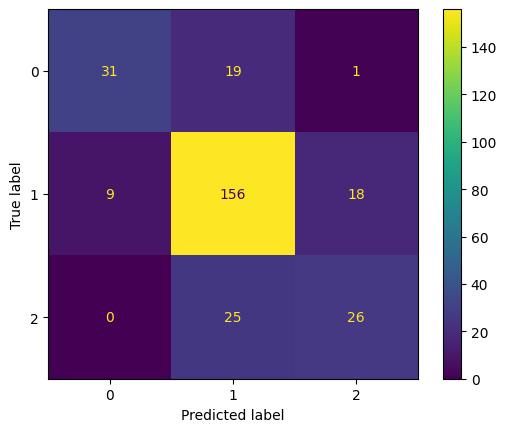

In [17]:
# Best-params model with sample weights to upweight class 0
from sklearn.utils.class_weight import compute_class_weight

# Use best params from the tuned model, avoid duplicate random_state
best_params = v1_model.get_params()
best_params = {k: v for k, v in best_params.items() if k != 'random_state'}

# Build per-sample weights: balanced by class frequency, then optionally boost class 0
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_map = {cls: w for cls, w in zip(classes, class_weights)}

# Optional: additional boost for class 0 (set >1.0 to emphasize class 0 more)
class0_boost = 1.5  # change to e.g. 1.5 or 2.0 if you want stronger emphasis
if 0 in class_weight_map:
    class_weight_map[0] *= class0_boost

sample_weight = y_train.map(class_weight_map).astype(float).values
print("Class weights:", class_weight_map)

# Fit weighted model
model_weighted_v1 = XGBClassifier(**best_params, random_state=42)
model_weighted_v1.fit(X_train, y_train, sample_weight=sample_weight)

# Evaluate on validation and test
y_val_pred_w = model_weighted_v1.predict(X_val)
y_test_pred_w = model_weighted_v1.predict(X_test)

print("\nClassification Report (weighted, test):\n", classification_report(y_test, y_test_pred_w))
print("\nConfusion Matrix (weighted, test):\n", ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_w))

## V2 model with more features

Added start/end value and volatility feautres + hyperparameter tuning + samle_weight + threshold tuning

In [18]:
filepath = '../data/raw/GT_V2_data_cph.csv'
data = pd.read_csv(filepath)
data.head()

,cluster_id,EMUB_reg_1990_1995,EMUB_reg_1995_2000,EMUB_reg_2000_2005,EMUB_reg_2005_2010,EMUB_reg_2010_2015,EMUB_reg_2015_2020,PMB_reg_1990_1995,PMB_reg_1995_2000,PMB_reg_2000_2005,...,public_housing_std_2000_2005,public_housing_std_2005_2010,public_housing_std_2010_2015,public_housing_std_2015_2020,unemp_std_1990_1995,unemp_std_1995_2000,unemp_std_2000_2005,unemp_std_2005_2010,unemp_std_2010_2015,unemp_std_2015_2020
0,101_1,28.597450,-29.508971,-8.305425,-10.737765,-18.739771,21.651561,1.006311,0.810537,1.273032,...,0.016733,0.024221,0.032863,0.010954,0.970788,0.688128,0.709598,0.880665,0.591041,1.302702
1,101_10,6.118231,-3.252824,3.160862,-1.795472,-7.849762,-7.569549,40.231621,-12.639138,4.562269,...,0.000000,0.000000,0.000000,0.000000,1.479157,1.042160,1.020804,2.021873,0.985894,1.197909
2,101_100,16.270826,-9.405488,1.413428,0.696864,9.424946,-1.370276,-25.301205,17.096774,24.903581,...,0.000000,0.000000,0.000000,0.000000,1.961616,4.803055,2.371906,2.198697,0.801758,0.870205
3,101_1000,18.296847,-0.560272,13.539355,-6.451128,-3.552484,-16.666667,35.381356,101.251956,-20.762053,...,0.000000,0.000000,0.000000,0.000000,2.798931,1.666957,1.241274,1.674763,1.326147,1.771727
4,101_1001,-4.456372,-2.743663,6.824288,-2.665996,3.165375,-4.946775,24.788136,-7.809847,-21.362799,...,0.052440,0.021370,0.013292,0.010954,0.732004,1.315502,0.468931,0.853534,0.415724,0.718192


In [19]:
data.shape


(1421, 267)

In [20]:
# Join 'mean_sd_class_idx' onto the dataset via 'cluster_id' with robust key handling

def _ensure_cluster_id(df):
    if 'cluster_id' in df.columns:
        return df
    # Case-insensitive exact match
    matches = [c for c in df.columns if c.lower() == 'cluster_id']
    if matches:
        df = df.rename(columns={matches[0]: 'cluster_id'})
        return df
    # Heuristic fallback: any column containing 'cluster' or 'munic'
    heur = [c for c in df.columns if ('cluster' in c.lower()) or ('munic' in c.lower())]
    if heur:
        print(f"INFO: Using '{heur[0]}' as 'cluster_id'")
        df = df.rename(columns={heur[0]: 'cluster_id'})
        return df
    raise KeyError("No join key found. Expected a 'cluster_id' column (case-insensitive) or one containing 'cluster'/'munic'.")

# Normalize join keys
data = _ensure_cluster_id(data)
STA_data = _ensure_cluster_id(STA_data)

# Determine which label column to use from STA_data
label_col = 'mean_sd_class_idx'
if label_col not in STA_data.columns:
    if 'mean_sd_class3_idx' in STA_data.columns:
        print("WARNING: 'mean_sd_class_idx' not found in STA_data; using 'mean_sd_class3_idx' instead.")
        label_col = 'mean_sd_class3_idx'
    else:
        raise KeyError("STA_data is missing 'mean_sd_class_idx' (and 'mean_sd_class3_idx'). Available columns: " + str(list(STA_data.columns)))

# Prepare right-side frame and align column name to 'mean_sd_class_idx' for consistency
right = STA_data[['cluster_id', label_col]].copy()
if label_col != 'mean_sd_class_idx':
    right = right.rename(columns={label_col: 'mean_sd_class_idx'})

# Merge
n_before = len(data)
data = data.merge(right, on='cluster_id', how='left')
missing = data['mean_sd_class_idx'].isna().sum()
print(f"Merged rows: {len(data)} (was {n_before}). Missing labels after merge: {missing}")

# Preview
data[['cluster_id', 'mean_sd_class_idx']].head()

Merged rows: 1421 (was 1421). Missing labels after merge: 0


,cluster_id,mean_sd_class_idx
0,101_1,2
1,101_10,1
2,101_100,1
3,101_1000,1
4,101_1001,2


In [21]:
X = data.drop(columns= {'cluster_id', 'mean_sd_class_idx' }, axis=1)
y = data['mean_sd_class_idx']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify = y_train)    

v2_model = XGBClassifier(random_state=42)
v2_model.fit(X_train, y_train)

#objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,  forskellig parametre vi kan bruge

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)


Test Accuracy (V2):
 0.8070175438596491

Test Classification Report (V2):
               precision    recall  f1-score   support

           0       0.83      0.59      0.69        51
           1       0.81      0.92      0.86       183
           2       0.78      0.63      0.70        51

    accuracy                           0.81       285
   macro avg       0.81      0.71      0.75       285
weighted avg       0.81      0.81      0.80       285


Test Confusion Matrix (V2):


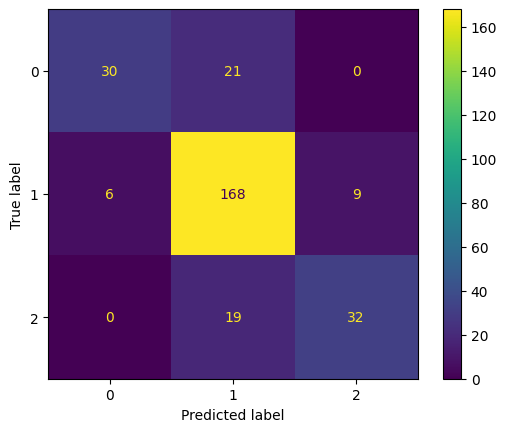

In [22]:
# Validation metrics for V2 model (align predictions with y_val)

# Optionally, evaluate on test as well for completeness
y_test_pred_v2 = v2_model.predict(X_test)
test_accuracy_v2 = accuracy_score(y_test, y_test_pred_v2)
print("\nTest Accuracy (V2):\n", test_accuracy_v2)
print("\nTest Classification Report (V2):\n", classification_report(y_test, y_test_pred_v2))
print("\nTest Confusion Matrix (V2):\n", ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_v2))

In [23]:
# Hyper parameter tuning

param_grid = {
    'n_estimators': [100, 200, 300, 500], # antallet af træer
    'learning_rate': [0.01, 0.1, 0.2], # hvor hurtigt modellen ændre i vægtene
    'max_depth': [3, 6, 9], # dybden af hvert træ
    'min_child_weight': [1, 3, 5], # minimum vægt for at en node kan deles
    'subsample': [0.7, 0.85, 1.0], # andel af træningsdata brugt til hvert træ
    'colsample_bytree': [0.7, 0.85, 1.0], # andel af features brugt til hvert træ
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100], # L1 regularization 
    'reg_lambda': [0.5, 0.7, 1, 1.3] # L2 regularization
}

model = XGBClassifier(random_state=42)


grid_seach = RandomizedSearchCV(model, param_grid, cv = 10, scoring='f1_macro', n_iter=100, n_jobs= -1, verbose = 2, random_state = 42)
grid_seach.fit(X_train, y_train)

v2_model = grid_seach.best_estimator_

print("Best Hyperparameters: ", grid_seach.best_params_)
print("best accuracy: ", grid_seach.best_score_ )


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=  19.1s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=  19.3s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=  19.4s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=  19.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=0.7, subsample=0.7; total time=  19.8s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500


Test Accuracy:
 0.7964912280701755

Test Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.57      0.70        51
           1       0.80      0.91      0.85       183
           2       0.70      0.63      0.66        51

    accuracy                           0.80       285
   macro avg       0.80      0.70      0.74       285
weighted avg       0.80      0.80      0.79       285


Test Confusion Matrix:


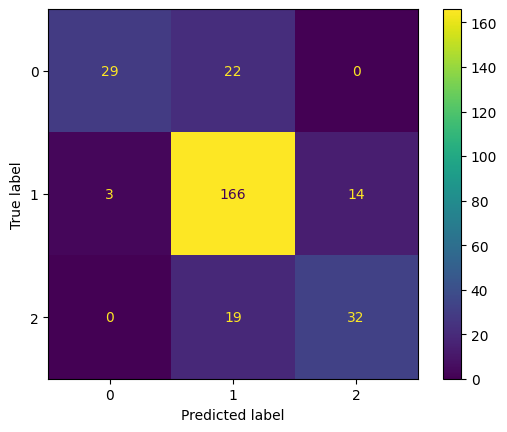

In [24]:
#Predction with the tuned model

# Generate predictions test splits
y_test_pred_best = v2_model.predict(X_test)

# Compute accuracies
test_accuracy = accuracy_score(y_test, y_test_pred_best)


# Print test metrics (y_test vs y_test_pred_best)
print("\nTest Accuracy:\n", test_accuracy)
print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred_best))
print("\nTest Confusion Matrix:\n", ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_best))

Class weights: {np.int64(0): np.float64(2.8211920529801326), np.int64(1): np.float64(0.5201465201465202), np.int64(2): np.float64(1.832258064516129)}

Classification Report (weighted, test):
               precision    recall  f1-score   support

           0       0.84      0.73      0.78        51
           1       0.85      0.88      0.86       183
           2       0.71      0.71      0.71        51

    accuracy                           0.82       285
   macro avg       0.80      0.77      0.78       285
weighted avg       0.82      0.82      0.82       285


Confusion Matrix (weighted, test):


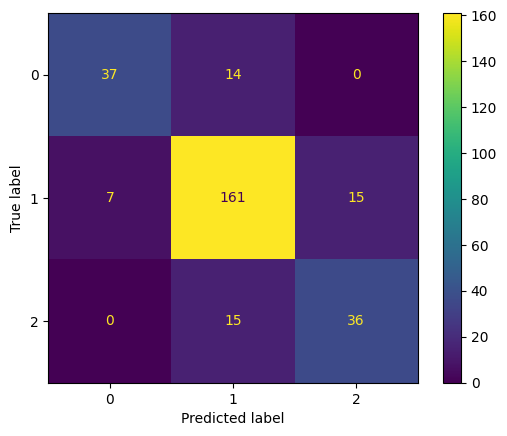

In [25]:
# Best-params model with sample weights to upweight class 0
from sklearn.utils.class_weight import compute_class_weight

# Use best params from the tuned model, avoid duplicate random_state
best_params = v2_model.get_params()
best_params = {k: v for k, v in best_params.items() if k != 'random_state'}

# Build per-sample weights: balanced by class frequency, then optionally boost class 0
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_map = {cls: w for cls, w in zip(classes, class_weights)}

# Optional: additional boost for class 0 (set >1.0 to emphasize class 0 more)
class0_boost = 1.5  # change to e.g. 1.5 or 2.0 if you want stronger emphasis
if 0 in class_weight_map:
    class_weight_map[0] *= class0_boost

sample_weight = y_train.map(class_weight_map).astype(float).values
print("Class weights:", class_weight_map)

# Fit weighted model
model_weighted_v2 = XGBClassifier(**best_params, random_state=42)
model_weighted_v2.fit(X_train, y_train, sample_weight=sample_weight)

# Evaluate on validation and test
y_val_pred_w = model_weighted_v2.predict(X_val)
y_test_pred_w = model_weighted_v2.predict(X_test)

print("\nClassification Report (weighted, test):\n", classification_report(y_test, y_test_pred_w))
print("\nConfusion Matrix (weighted, test):\n", ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_w))

### Threshold tuning

Reference best threshold (validation, weighted model; F1-optimized): 0.800
Recall0=0.667, Precision0=0.895, F1_0=0.764


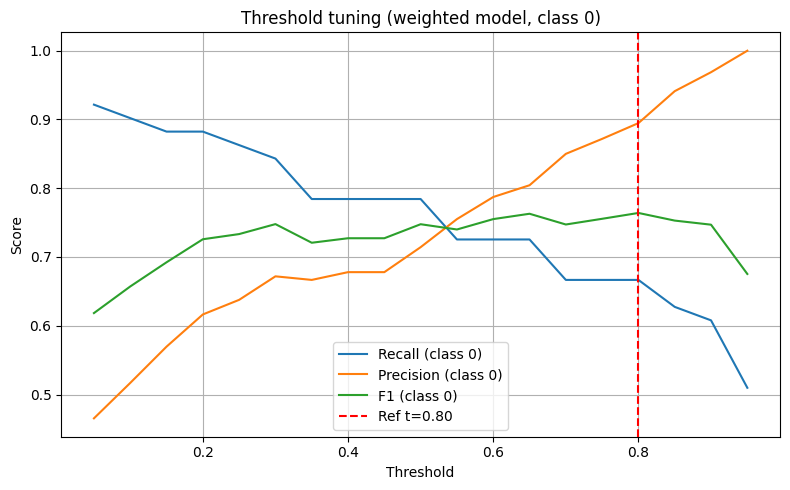

Using final threshold best_t=0.30 by project choice.

Classification Report (test, tuned threshold=0.30; class 0 positive; weighted model):
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       234
           1       0.75      0.78      0.77        51

    accuracy                           0.92       285
   macro avg       0.85      0.86      0.86       285
weighted avg       0.92      0.92      0.92       285


Confusion Matrix (test, tuned threshold=0.30; class 0 positive; weighted model):


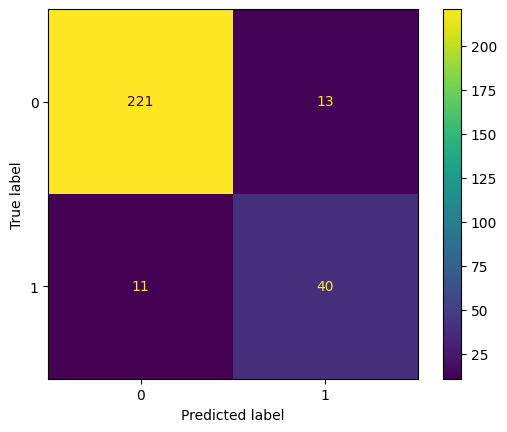


Classification Report (test, tuned threshold=0.30; multiclass; weighted model):
               precision    recall  f1-score   support

           0       0.75      0.78      0.77        51
           1       0.86      0.85      0.85       183
           2       0.71      0.71      0.71        51

    accuracy                           0.81       285
   macro avg       0.77      0.78      0.78       285
weighted avg       0.81      0.81      0.81       285


Confusion Matrix (test, tuned threshold=0.30; multiclass; weighted model):


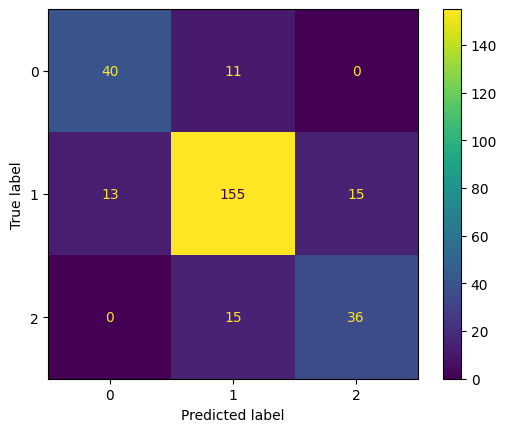

In [26]:
# Threshold tuning for model_weighted optimizing F1 for class 0 (binary: class 0 vs others)

# Ensure weighted model exists and supports probabilities
if 'model_weighted_v2' not in globals():
    raise RuntimeError("model_weighted_v2 is not defined. Train the weighted model before threshold tuning.")
if not hasattr(model_weighted_v2, 'predict_proba'):
    raise RuntimeError('model_weighted_v2 does not support predict_proba. Ensure it is a probabilistic classifier.')

# Map original multiclass labels to binary where class 0 is positive (1) and all others are negative (0)
y_val_bin = (y_val == 0).astype(int)
y_test_bin = (y_test == 0).astype(int)

# Get probability for class 0 specifically using the weighted model
proba_val_all = model_weighted_v2.predict_proba(X_val)
proba_test_all = model_weighted_v2.predict_proba(X_test)
if hasattr(model_weighted_v2, 'classes_') and (0 in list(model_weighted_v2.classes_)):
    idx_class0 = list(model_weighted_v2.classes_).index(0)
    y_val_prob0 = proba_val_all[:, idx_class0]
    y_test_prob0 = proba_test_all[:, idx_class0]
else:
    # Fallback: use the first column as class 0 probability if classes_ not available
    y_val_prob0 = proba_val_all[:, 0]
    y_test_prob0 = proba_test_all[:, 0]

# Sweep thresholds to maximize F1 of class 0 (tie-breaker: Precision for class 0)
ts = np.linspace(0.05, 0.95, 19)
recall0s, precision0s, f10s = [], [], []
for t in ts:
    y_val_pred_bin = (y_val_prob0 >= t).astype(int)  # 1 predicts class 0
    recall0 = recall_score(y_val_bin, y_val_pred_bin, pos_label=1)
    precision0 = precision_score(y_val_bin, y_val_pred_bin, pos_label=1, zero_division=0)
    f10 = f1_score(y_val_bin, y_val_pred_bin, pos_label=1, zero_division=0)
    recall0s.append(recall0)
    precision0s.append(precision0)
    f10s.append(f10)

# Choose threshold by best F1; tie-break by higher precision (for reference)
best_idx = int(np.argmax(f10s))
best_candidates = np.where(np.isclose(f10s, f10s[best_idx]))[0]
best_idx = best_candidates[int(np.argmax([precision0s[i] for i in best_candidates]))]
ref_t = float(ts[best_idx])

print(f"Reference best threshold (validation, weighted model; F1-optimized): {ref_t:.3f}")
print(f"Recall0={recall0s[best_idx]:.3f}, Precision0={precision0s[best_idx]:.3f}, F1_0={f10s[best_idx]:.3f}")

# Plot metrics vs threshold (keep graphs)
plt.figure(figsize=(8,5))
plt.plot(ts, recall0s, label='Recall (class 0)')
plt.plot(ts, precision0s, label='Precision (class 0)')
plt.plot(ts, f10s, label='F1 (class 0)')
plt.axvline(ref_t, color='red', linestyle='--', label=f'Ref t={ref_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold tuning (weighted model, class 0)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final chosen threshold for downstream predictions (override to 0.3 for project needs)
best_t = 0.3
print(f"Using final threshold best_t={best_t:.2f} by project choice.")

# Evaluate on test set at chosen threshold (binary report)
y_test_pred_bin = (y_test_prob0 >= best_t).astype(int)
print(f"\nClassification Report (test, tuned threshold={best_t:.2f}; class 0 positive; weighted model):\n", classification_report(y_test_bin, y_test_pred_bin))
print(f"\nConfusion Matrix (test, tuned threshold={best_t:.2f}; class 0 positive; weighted model):")
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_test_pred_bin)
plt.show()

# Multiclass report at tuned threshold (includes classes 0/1/2)
# Rule: if class0_prob >= best_t -> predict class 0; else predict argmax among classes from the weighted model
classes = list(getattr(model_weighted_v2, 'classes_', np.array([0,1,2])))
proba_argmax = np.argmax(proba_test_all, axis=1)
# Map argmax indices to original class labels
argmax_labels = np.array([classes[i] if i < len(classes) else i for i in proba_argmax])
# Apply threshold rule
y_test_pred_multi = np.where(y_test_prob0 >= best_t, 0, argmax_labels)

print(f"\nClassification Report (test, tuned threshold={best_t:.2f}; multiclass; weighted model):\n", classification_report(y_test, y_test_pred_multi))
print(f"\nConfusion Matrix (test, tuned threshold={best_t:.2f}; multiclass; weighted model):")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_multi)
plt.show()

In [27]:
# Save threshold tuning plot to JPEG under results/models
import os

# Ensure weighted model and validation data are available
if 'model_weighted_v2' not in globals():
    raise RuntimeError("model_weighted_v2 is not defined. Run the threshold tuning cell first.")

# Prepare validation binary labels and class-0 probabilities
y_val_bin = (y_val == 0).astype(int)
proba_val_all = model_weighted_v2.predict_proba(X_val)
classes = list(getattr(model_weighted_v2, 'classes_', np.array([0, 1, 2])))
idx_class0 = classes.index(0) if 0 in classes else 0
y_val_prob0 = proba_val_all[:, idx_class0]

# Sweep thresholds and compute metrics
ts = np.linspace(0.05, 0.95, 19)
recall0s, precision0s, f10s = [], [], []
for t in ts:
    y_val_pred_bin = (y_val_prob0 >= t).astype(int)
    recall0s.append(recall_score(y_val_bin, y_val_pred_bin, pos_label=1))
    precision0s.append(precision_score(y_val_bin, y_val_pred_bin, pos_label=1, zero_division=0))
    f10s.append(f1_score(y_val_bin, y_val_pred_bin, pos_label=1, zero_division=0))

# Reference best threshold
best_idx = int(np.argmax(f10s))
best_candidates = np.where(np.isclose(f10s, f10s[best_idx]))[0]
best_idx = best_candidates[int(np.argmax([precision0s[i] for i in best_candidates]))]
ref_t = float(ts[best_idx])

# Create plot identical to the tuning cell (without chosen threshold line)
fig = plt.figure(figsize=(8, 5))
plt.plot(ts, recall0s, label='Recall (class 0)')
plt.plot(ts, precision0s, label='Precision (class 0)')
plt.plot(ts, f10s, label='F1 (class 0)')
plt.axvline(ref_t, color='red', linestyle='--', label=f'Ref t={ref_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold tuning (weighted model, class 0)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save as JPEG
out_path = os.path.join('..', 'results', 'models', 'threshold_tuning_plot.jpg')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, format='jpeg', dpi=300)
plt.close(fig)
print(f"Saved threshold tuning plot to: {out_path}")

Saved threshold tuning plot to: ../results/models/threshold_tuning_plot.jpg


In [28]:
# Save test predictions (only cluster_id and prediction) using weighted model and tuned threshold
import os
import numpy as np

# Choose model: prefer weighted V2, fall back to tuned V2
clf = globals().get('model_weighted_v2', None) or globals().get('v2_model', None)
if clf is None:
    raise RuntimeError("No trained model found. Train v2_model or model_weighted_v2 first.")

# Get probabilities on X_test to align with cluster_id index
if not hasattr(clf, 'predict_proba'):
    # Fallback: direct predictions without thresholding
    pred_labels = clf.predict(X_test)
else:
    proba_test_all = clf.predict_proba(X_test)
    classes = list(getattr(clf, 'classes_', np.array([0, 1, 2])))
    best_t = globals().get('best_t', 0.30)

    # Probability for class 0
    idx_class0 = classes.index(0) if 0 in classes else 0
    prob0 = proba_test_all[:, idx_class0]

    # Argmax fallback when below threshold
    argmax_indices = np.argmax(proba_test_all, axis=1)
    argmax_labels = np.array([classes[i] if i < len(classes) else i for i in argmax_indices])

    # Apply threshold rule
    pred_labels = np.where(prob0 >= best_t, 0, argmax_labels)

# Build and save slim CSV aligned to X_test indices
pred_df = pd.DataFrame({
    'cluster_id': data.loc[X_test.index, 'cluster_id'],
    'prediction': pred_labels
})

out_path = os.path.join('..', 'results', 'models', 'predictions_cph.csv')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
pred_df.to_csv(out_path, index=False)
print(f"Saved predictions to: {out_path}; rows={len(pred_df)}")

Saved predictions to: ../results/models/predictions_cph.csv; rows=285


## Fitting model to new data

Testing the model in a real world scenario on all the neighborhoods in the 34 Finger plan municiplalities

In [55]:
#filepath = "../data/raw/GT_V3_denmark.csv" #Changed to whole denmark dataset
filepath = "../data/raw/GT_V1_data_finger.csv"
data_finger = pd.read_csv(filepath)
data_finger.head()


,cluster_id,EMUB_reg_1990_1995,EMUB_reg_1995_2000,EMUB_reg_2000_2005,EMUB_reg_2005_2010,EMUB_reg_2010_2015,EMUB_reg_2015_2020,PMB_reg_1990_1995,PMB_reg_1995_2000,PMB_reg_2000_2005,...,public_housing_std_2000_2005,public_housing_std_2005_2010,public_housing_std_2010_2015,public_housing_std_2015_2020,unemp_std_1990_1995,unemp_std_1995_2000,unemp_std_2000_2005,unemp_std_2005_2010,unemp_std_2010_2015,unemp_std_2015_2020
0,101_1,28.597450,-29.508971,-8.305425,-10.737765,-18.739771,21.651561,1.006311,0.810537,1.273032,...,0.016733,0.024221,0.032863,0.010954,0.970788,0.688128,0.709598,0.880665,0.591041,1.302702
1,101_10,6.118231,-3.252824,3.160862,-1.795472,-7.849762,-7.569549,40.231621,-12.639138,4.562269,...,0.000000,0.000000,0.000000,0.000000,1.479157,1.042160,1.020804,2.021873,0.985894,1.197909
2,101_100,16.270826,-9.405488,1.413428,0.696864,9.424946,-1.370276,-25.301205,17.096774,24.903581,...,0.000000,0.000000,0.000000,0.000000,1.961616,4.803055,2.371906,2.198697,0.801758,0.870205
3,101_1000,18.296847,-0.560272,13.539355,-6.451128,-3.552484,-16.666667,35.381356,101.251956,-20.762053,...,0.000000,0.000000,0.000000,0.000000,2.798931,1.666957,1.241274,1.674763,1.326147,1.771727
4,101_1001,-4.456372,-2.743663,6.824288,-2.665996,3.165375,-4.946775,24.788136,-7.809847,-21.362799,...,0.052440,0.021370,0.013292,0.010954,0.732004,1.315502,0.468931,0.853534,0.415724,0.718192


In [56]:
data_finger.shape

(4020, 267)

In [53]:
# add new prediction feature to the dataset

data_finger['prediction'] = np.nan
print("Added 'prediction' column with NaN values. Preview:")
print(data_finger[['cluster_id', 'prediction']].head())

Added 'prediction' column with NaN values. Preview:
  cluster_id  prediction
0      101_1         NaN
1     101_10         NaN
2    101_100         NaN
3   101_1000         NaN
4   101_1001         NaN


In [ ]:
# Predict classes for new finger plan dataset using the weighted model and tuned threshold
import os
import numpy as np
import pandas as pd

# Choose model: prefer weighted V2, otherwise tuned V2
clf = globals().get('model_weighted_v2', None) or globals().get('v2_model', None)
if clf is None:
    raise RuntimeError("No trained model found. Train v2_model or model_weighted_v2 first.")

# Determine the feature list the model was trained with
model_features = list(getattr(clf, 'feature_names_in_', []))
if not model_features:
    try:
        booster = clf.get_booster()
        model_features = booster.feature_names or []
    except Exception:
        model_features = []
if not model_features:
    # Fallback to previously defined X if available
    if 'X' in globals():
        model_features = list(X.columns)
    else:
        raise RuntimeError("Unable to determine model feature names. Ensure the model was fit on a DataFrame or provide X.")

# Build feature matrix for data_finger exactly matching model features
X_finger_raw = data_finger.copy()
missing_cols = [c for c in model_features if c not in X_finger_raw.columns]
for c in missing_cols:
    X_finger_raw[c] = 0

# Keep only model features and in the same order; coerce to numeric
X_finger = X_finger_raw[model_features].apply(pd.to_numeric, errors='coerce').fillna(0)

# Predict probabilities if available, else direct predictions
if hasattr(clf, 'predict_proba'):
    proba_finger_all = clf.predict_proba(X_finger)
    classes = list(getattr(clf, 'classes_', np.array([0, 1, 2])))

    # Use tuned threshold; default to 0.30 if not defined
    best_t = globals().get('best_t', 0.30)

    # Probability for class 0
    idx_class0 = classes.index(0) if 0 in classes else 0
    prob0 = proba_finger_all[:, idx_class0]

    # Argmax fallback when prob0 < threshold
    argmax_indices = np.argmax(proba_finger_all, axis=1)
    argmax_labels = np.array([classes[i] if i < len(classes) else i for i in argmax_indices])

    # Apply threshold rule
    pred_labels = np.where(prob0 >= best_t, 0, argmax_labels)
else:
    pred_labels = clf.predict(X_finger)

# Assign predictions to dataframe
data_finger['prediction'] = pred_labels

# Preview and save (only cluster_id and prediction)
print("Preview predictions (first 5):")
print(data_finger[['cluster_id', 'prediction']].head())
try:
    #out_path = os.path.join('..', 'results', 'models', 'DK_predictions.csv')
    out_path = os.path.join('..', 'results', 'models', 'finger_predictions.csv')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    pred_save = data_finger[['cluster_id', 'prediction']].copy()
    pred_save.to_csv(out_path, index=False)
    print(f"Saved predictions to: {out_path}; rows={len(pred_save)}")
except Exception as e:
    print("Warning: could not save predictions:", e)

Preview predictions (first 5):
  cluster_id  prediction
0      101_1           2
1     101_10           1
2    101_100           2
3   101_1000           1
4   101_1001           2
Saved predictions to: ../results/models/DK_predictions.csv; rows=9177
